./output_s_space_0_factor_1/axis_0_counts_xi_ndata_3484390_nrand_3484390_seed_0.out max |Δxi| = 0.000e+00
./output_s_space_0_factor_1/axis_1_counts_xi_ndata_3484390_nrand_3484390_seed_0.out max |Δxi| = 0.000e+00
./output_s_space_0_factor_1/axis_2_counts_xi_ndata_3484390_nrand_3484390_seed_0.out max |Δxi| = 0.000e+00


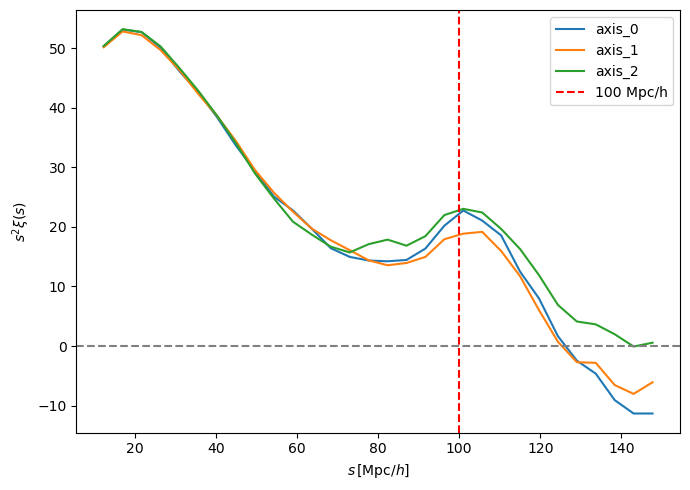

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import glob

# Folder where you saved outputs
folder = "./output_s_space_*_factor_*/"

# Collect all files (e.g. all axes or seeds)
files = sorted(glob.glob(folder + "axis_*_counts_xi_*.out"))

plt.figure(figsize=(7,5))

for fname in files:
    data = np.loadtxt(fname)
    
    s   = data[:,0]
    DD  = data[:,1]
    DR  = data[:,2]
    RR  = data[:,3]
    xi_saved = data[:,4]

    # --- Recompute Landy–Szalay explicitly ---
    xi_LS = (DD - 2*DR + RR) / RR

    # Optional sanity check
    diff = np.max(np.abs(xi_LS - xi_saved))
    print(f"{fname} max |Δxi| = {diff:.3e}")

    # Plot (you said you like s^2 xi)
    plt.plot(s, s**2 * xi_LS, label=fname.split("/")[-1][:6])

plt.axhline(0, ls="--", color="gray")
plt.axvline(100, ls="--", color="red", label="100 Mpc/h")
plt.xlabel(r"$s\,[\mathrm{Mpc}/h]$")
plt.ylabel(r"$s^2 \xi(s)$")
plt.legend()
plt.tight_layout()
plt.show()